<a href="https://colab.research.google.com/github/AndresLapSol/prediccion_sentimientos/blob/main/proyecto_sentimientos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MEDIDASES EN CM



## PREPROCESAMIENTO

In [42]:
import pandas as pd
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

input_file = '/content/drive/MyDrive/Colab Notebooks/RAFA/SAA/PROYECTO/dataset_sentimientos_formato_largo.csv'
df = pd.read_csv(input_file)

print("Shape original:", df.shape)
print("Columnas:", df.columns.tolist())

# Limpiar textos
df["GENERO"] = df["GENERO"].astype(str).str.strip().str.upper()
df["emocion"] = df["emocion"].astype(str).str.strip().str.lower()
df["punto_1"] = df["punto_1"].astype(str).str.strip().str.lower()
df["punto_2"] = df["punto_2"].astype(str).str.strip().str.lower()

# Convertir numéricos
df["EDAD"] = pd.to_numeric(df["EDAD"], errors="coerce")
df["distancia_cm"] = (
    df["distancia_cm"].astype(str)
    .str.replace(",", ".", regex=False)
    .str.strip()
)
df["distancia_cm"] = pd.to_numeric(df["distancia_cm"], errors="coerce")

# Ver nulos
print("\nNulos por columna:")
print(df.isnull().sum())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape original: (231, 6)
Columnas: ['GENERO', 'EDAD', 'punto_1', 'punto_2', 'emocion', 'distancia_cm']

Nulos por columna:
GENERO          0
EDAD            0
punto_1         0
punto_2         0
emocion         0
distancia_cm    8
dtype: int64


In [43]:
from sklearn.impute import SimpleImputer
import numpy as np

df_imputed = df.copy()

# Imputación numérica
imputer_num = SimpleImputer(strategy="mean")
num_cols = ["distancia_cm"]

df_imputed[num_cols] = pd.DataFrame(
    imputer_num.fit_transform(df_imputed[num_cols]),
    columns=num_cols,
    index=df_imputed.index
)

print("Nulos tras imputación:")
display(df_imputed.isnull().sum())

df_imputed

Nulos tras imputación:


,0
GENERO,0
EDAD,0
punto_1,0
punto_2,0
emocion,0
distancia_cm,0


,GENERO,EDAD,punto_1,punto_2,emocion,distancia_cm
0,F,17,2,3,miedo,5.2
1,F,17,2,6,miedo,2.2
2,F,17,6,8,miedo,3.6
3,F,17,8,9,miedo,4.0
4,F,17,7a,7b,miedo,1.6
...,...,...,...,...,...,...
226,M,40,8,9,alegría,2.2
227,M,40,7a,7b,alegría,0.5
228,M,40,2,18,alegría,2.5
229,M,40,6,7,alegría,1.1


In [44]:
from sklearn.preprocessing import LabelEncoder


df_model = df_imputed.copy()

# One-hot para GENERO
df_model = pd.get_dummies(df_model, columns=["GENERO"], drop_first=True)

# Label encoding de la variable objetivo
le_y = LabelEncoder()
df_model["emocion"] = le_y.fit_transform(df_model["emocion"])

# Convertir puntos a numérico
point_map = {
    "2": 2,
    "3": 3,
    "6": 6,
    "7": 7,
    "7a": 7.1,
    "7b": 7.2,
    "8": 8,
    "9": 9,
    "18": 18
}

df_model["punto_1"] = df_model["punto_1"].astype(str).str.lower().str.strip().map(point_map)
df_model["punto_2"] = df_model["punto_2"].astype(str).str.lower().str.strip().map(point_map)

print(df_model.head())
print(df_model["emocion"].value_counts())
print(df_model[["punto_1","punto_2"]].isnull().sum())

   EDAD  punto_1  punto_2  emocion  distancia_cm  GENERO_M
0    17      2.0      3.0        4           5.2     False
1    17      2.0      6.0        4           2.2     False
2    17      6.0      8.0        4           3.6     False
3    17      8.0      9.0        4           4.0     False
4    17      7.1      7.2        4           1.6     False
emocion
4    33
5    33
2    33
3    33
6    33
0    33
1    33
Name: count, dtype: int64
punto_1    0
punto_2    0
dtype: int64


In [45]:
from sklearn.model_selection import train_test_split

# Separar variables predictoras y variable objetivo
X = df_model.drop("emocion", axis=1)
y = df_model["emocion"]

# Dividir en entrenamiento y prueba
# stratify=y mantiene la proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Comprobar el tamaño de cada subconjunto
print("\nShapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


Shapes:
X_train: (184, 5)
X_test: (47, 5)
y_train: (184,)
y_test: (47,)


In [46]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Crear el objeto SMOTE para generar datos sintéticos
# random_state fija la aleatoriedad para obtener siempre el mismo resultado
smote = SMOTE(random_state=42)

# Aplicar SMOTE solo sobre el conjunto de entrenamiento
# Esto evita contaminar el conjunto de prueba
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Ver la distribución original de clases en entrenamiento
print("Distribución original en entrenamiento:")
print(y_train.value_counts())

# Ver la distribución tras aplicar SMOTE
print("\nDistribución tras SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# Comprobar el nuevo tamaño del conjunto sintético
print("\nShapes:")
print("X_train_smote:", X_train_smote.shape)
print("y_train_smote:", y_train_smote.shape)

Distribución original en entrenamiento:
emocion
1    27
0    27
6    26
4    26
3    26
5    26
2    26
Name: count, dtype: int64

Distribución tras SMOTE:
emocion
6    27
1    27
4    27
3    27
5    27
2    27
0    27
Name: count, dtype: int64

Shapes:
X_train_smote: (189, 5)
y_train_smote: (189,)


# ÁRBOLES


Mejor max_depth: 1 con accuracy: 0.1587


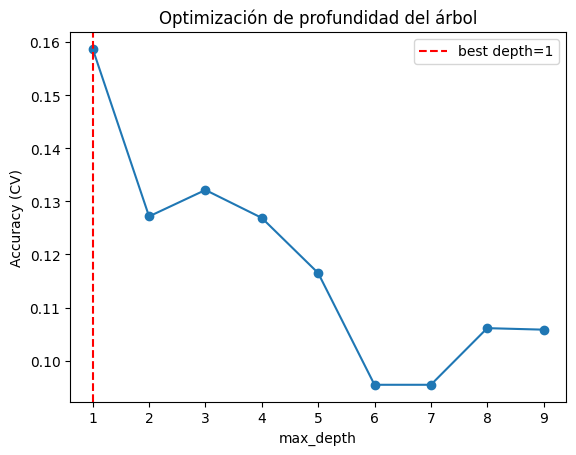

In [47]:
from sklearn import tree
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import pandas as pd

# Combinar train_smote para la validación cruzada
import numpy as np
X_cv = pd.DataFrame(X_train_smote, columns=X_train.columns)
y_cv = pd.Series(y_train_smote)

# KFold con shuffle porque nuestros datos no son series temporales
cv = KFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
max_attributes = X_cv.shape[1]
depth_range = range(1, max_attributes * 2)

# Buscar la mejor profundidad máxima
for depth in depth_range:
    fold_accuracy = []
    tree_model = tree.DecisionTreeClassifier(
        criterion='entropy',
        max_depth=depth,
        class_weight='balanced',
        random_state=42
    )

    for train_fold, test_fold in cv.split(X_cv):
        f_train_X = X_cv.iloc[train_fold]
        f_test_X  = X_cv.iloc[test_fold]
        f_train_y = y_cv.iloc[train_fold]
        f_test_y  = y_cv.iloc[test_fold]

        model = tree_model.fit(f_train_X, f_train_y)
        test_acc = model.score(f_test_X, f_test_y)
        fold_accuracy.append(test_acc)

    avg = sum(fold_accuracy) / len(fold_accuracy)
    accuracies.append(avg)

# Mejor profundidad
best_depth = depth_range[accuracies.index(max(accuracies))]
print(f"Mejor max_depth: {best_depth} con accuracy: {max(accuracies):.4f}")

plt.plot(depth_range, accuracies, marker='o')
plt.xlabel('max_depth')
plt.ylabel('Accuracy (CV)')
plt.title('Optimización de profundidad del árbol')
plt.axvline(x=best_depth, color='red', linestyle='--', label=f'best depth={best_depth}')
plt.legend()
plt.show()

In [48]:
for depth in [2, 3, 4, 5, 6, 8, 10]:
    clf_test = tree.DecisionTreeClassifier(
        criterion='entropy',
        max_depth=depth,
        class_weight='balanced',
        random_state=42
    )
    clf_test.fit(X_train_smote, y_train_smote)
    acc_train = clf_test.score(X_train_smote, y_train_smote)
    acc_test  = clf_test.score(X_test, y_test)
    print(f"max_depth={depth} | Train: {acc_train:.4f} | Test: {acc_test:.4f}")

max_depth=2 | Train: 0.1852 | Test: 0.1064
max_depth=3 | Train: 0.2169 | Test: 0.1277
max_depth=4 | Train: 0.2751 | Test: 0.1277
max_depth=5 | Train: 0.3280 | Test: 0.1702
max_depth=6 | Train: 0.3968 | Test: 0.1277
max_depth=8 | Train: 0.5026 | Test: 0.0638
max_depth=10 | Train: 0.6349 | Test: 0.0426


In [49]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train_smote, y_train_smote)

acc_train_rf = rf.score(X_train_smote, y_train_smote)
acc_test_rf  = rf.score(X_test, y_test)

print(f"Random Forest | Train: {acc_train_rf:.4f} | Test: {acc_test_rf:.4f}")

Random Forest | Train: 0.7302 | Test: 0.0213


In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

# Regresión Logística
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train_smote, y_train_smote)
print(f"Logística | Train: {lr.score(X_train_smote, y_train_smote):.4f} | Test: {lr.score(X_test, y_test):.4f}")

# Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_smote, y_train_smote)
print(f"Boosting  | Train: {gb.score(X_train_smote, y_train_smote):.4f} | Test: {gb.score(X_test, y_test):.4f}")

Logística | Train: 0.1640 | Test: 0.0638
Boosting  | Train: 0.7037 | Test: 0.0638


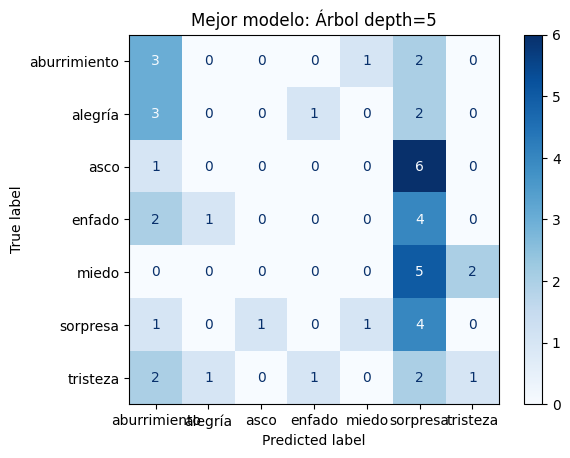

              precision    recall  f1-score   support

aburrimiento       0.25      0.50      0.33         6
     alegría       0.00      0.00      0.00         6
        asco       0.00      0.00      0.00         7
      enfado       0.00      0.00      0.00         7
       miedo       0.00      0.00      0.00         7
    sorpresa       0.16      0.57      0.25         7
    tristeza       0.33      0.14      0.20         7

    accuracy                           0.17        47
   macro avg       0.11      0.17      0.11        47
weighted avg       0.11      0.17      0.11        47



In [51]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

clf_final = tree.DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    class_weight='balanced',
    random_state=42
)
clf_final.fit(X_train_smote, y_train_smote)
preds_final = clf_final.predict(X_test)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, preds_final,
    display_labels=le_y.classes_,
    cmap='Blues'
)
disp.ax_.set_title('Mejor modelo: Árbol depth=5')
disp.ax_.grid(False)
plt.show()

print(classification_report(y_test, preds_final, target_names=le_y.classes_))

Tras probar el modelo con las distancias absolutas entre puntos faciales, observamos que los resultados eran muy bajos y que los algoritmos tendían a sobreajustar con facilidad. Por ello, decidimos cambiar a un segundo dataset basado en proporciones y coeficientes de variación entre distancias, ya que estas relaciones son más estables entre personas y ayudan a reducir el efecto del tamaño de la cara o de diferencias individuales. Además, al incorporar género y edad, el dataset conserva información contextual que puede ser útil para el entrenamiento. Este cambio busca mejorar la calidad de las variables de entrada y ofrecer una representación más adecuada para la clasificación de emociones faciales.

# PROPORCIONES Y COEFICIENTES


In [52]:
import pandas as pd
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

input_file = '/content/drive/MyDrive/Colab Notebooks/RAFA/SAA/PROYECTO/dataset_sentimientos_proporciones.csv'
df = pd.read_csv(input_file)

print(df.head())
print(df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  GENERO  EDAD punto_base punto_comparado MIEDO SORPRESA  ASCO ENFADO  \
0      F    17        2-6             2-3  0,42     0,51  0,43   0,51   
1      F    17        6-8             2-3  0,69     0,73  0,78   0,89   
2      F    17        8-9             2-3  0,77     0,76  0,93   1,02   
3      F    17      7A-7B             2-3  0,31     0,33   0,2   0,22   
4      F    17       2-18             2-3  0,62     0,82   0,8   0,91   

  TRISTEZA Aburrimiento ALEGRIA MEDIA DESV. EST coef. variación  
0     0,44         0,58    0,43  0,48     0,061    0,1280446648  
1      0,7         0,85    0,79  0,78     0,076   0,09739331691  
2     0,86         0,83    0,85  0,86      0,09    0,1050392115  
3     0,14         0,25    0,13  0,23     0,076     0,334029716  
4     0,78         0,88    0,64  0,78     0,111    0,1431075078  
(76, 14)


In [53]:
# Copia para no tocar el original
df_model = df.copy()

# Normalizar nombres de columnas
df_model.columns = df_model.columns.str.strip()

# Cambiar coma decimal por punto y convertir a numérico
cols_num = [
    "MIEDO", "SORPRESA", "ASCO", "ENFADO",
    "TRISTEZA", "Aburrimiento", "ALEGRIA",
    "MEDIA", "DESV. EST", "coef. variación"
]

for col in cols_num:
    df_model[col] = df_model[col].astype(str).str.replace(",", ".", regex=False)
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# Revisar nulos por si alguna conversión falló
print(df_model.isnull().sum())

# Ver resultado
print(df_model.head())
print(df_model.dtypes)

GENERO             0
EDAD               0
punto_base         0
punto_comparado    0
MIEDO              0
SORPRESA           0
ASCO               0
ENFADO             0
TRISTEZA           0
Aburrimiento       7
ALEGRIA            0
MEDIA              7
DESV. EST          7
coef. variación    7
dtype: int64
  GENERO  EDAD punto_base punto_comparado  MIEDO  SORPRESA  ASCO  ENFADO  \
0      F    17        2-6             2-3   0.42      0.51  0.43    0.51   
1      F    17        6-8             2-3   0.69      0.73  0.78    0.89   
2      F    17        8-9             2-3   0.77      0.76  0.93    1.02   
3      F    17      7A-7B             2-3   0.31      0.33  0.20    0.22   
4      F    17       2-18             2-3   0.62      0.82  0.80    0.91   

   TRISTEZA  Aburrimiento  ALEGRIA  MEDIA  DESV. EST  coef. variación  
0      0.44          0.58     0.43   0.48      0.061         0.128045  
1      0.70          0.85     0.79   0.78      0.076         0.097393  
2      0.86         

In [54]:
df_model[df_model[['Aburrimiento', 'MEDIA', 'DESV. EST', 'coef. variación']].isnull().any(axis=1)]

,GENERO,EDAD,punto_base,punto_comparado,MIEDO,SORPRESA,ASCO,ENFADO,TRISTEZA,Aburrimiento,ALEGRIA,MEDIA,DESV. EST,coef. variación
69,M,40,2-6,2-3,0.33,0.38,0.29,0.25,0.27,NaN,0.28,NaN,NaN,NaN
70,M,40,6-8,2-3,0.56,0.50,0.69,0.73,0.32,NaN,0.56,NaN,NaN,NaN
71,M,40,8-9,2-3,0.62,0.75,0.71,0.78,0.68,NaN,0.61,NaN,NaN,NaN
72,M,40,7A-7B,2-3,0.20,0.23,0.19,0.18,0.14,NaN,0.14,NaN,NaN,NaN
73,M,40,2-18,2-3,0.60,0.58,0.95,0.75,0.68,NaN,0.69,NaN,NaN,NaN
74,M,40,6-7,2-3,0.24,0.25,0.24,0.33,0.19,NaN,0.31,NaN,NaN,NaN
75,M,40,3-8,2-3,0.33,0.30,0.26,0.13,0.27,NaN,0.28,NaN,NaN,NaN


In [55]:
# Rellenar los valores nulos de algunas columnas numéricas con la media de cada columna
for col in ['Aburrimiento', 'MEDIA', 'DESV. EST', 'coef. variación']:
    df_model[col] = df_model[col].fillna(df_model[col].mean())

# Comprobar cuántos valores nulos quedan en cada columna del dataframe
print(df_model.isnull().sum())

# Mostrar el dataframe final para revisar cómo ha quedado después de la imputación
df_model

GENERO             0
EDAD               0
punto_base         0
punto_comparado    0
MIEDO              0
SORPRESA           0
ASCO               0
ENFADO             0
TRISTEZA           0
Aburrimiento       0
ALEGRIA            0
MEDIA              0
DESV. EST          0
coef. variación    0
dtype: int64


,GENERO,EDAD,punto_base,punto_comparado,MIEDO,SORPRESA,ASCO,ENFADO,TRISTEZA,Aburrimiento,ALEGRIA,MEDIA,DESV. EST,coef. variación
0,F,17,2-6,2-3,0.42,0.51,0.43,0.51,0.44,0.580000,0.43,0.480000,0.061000,0.128045
1,F,17,6-8,2-3,0.69,0.73,0.78,0.89,0.70,0.850000,0.79,0.780000,0.076000,0.097393
2,F,17,8-9,2-3,0.77,0.76,0.93,1.02,0.86,0.830000,0.85,0.860000,0.090000,0.105039
3,F,17,7A-7B,2-3,0.31,0.33,0.20,0.22,0.14,0.250000,0.13,0.230000,0.076000,0.334030
4,F,17,2-18,2-3,0.62,0.82,0.80,0.91,0.78,0.880000,0.64,0.780000,0.111000,0.143108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,M,40,8-9,2-3,0.62,0.75,0.71,0.78,0.68,1.206232,0.61,1.457391,0.362971,0.209221
72,M,40,7A-7B,2-3,0.20,0.23,0.19,0.18,0.14,1.206232,0.14,1.457391,0.362971,0.209221
73,M,40,2-18,2-3,0.60,0.58,0.95,0.75,0.68,1.206232,0.69,1.457391,0.362971,0.209221
74,M,40,6-7,2-3,0.24,0.25,0.24,0.33,0.19,1.206232,0.31,1.457391,0.362971,0.209221


In [56]:
import pandas as pd

# Lista de columnas que contienen las emociones
emotion_cols = ['MIEDO', 'SORPRESA', 'ASCO', 'ENFADO', 'TRISTEZA', 'Aburrimiento', 'ALEGRIA']

# Convertir esas columnas a tipo numérico por si alguna aún estuviera como texto
for c in emotion_cols:
    df_model[c] = pd.to_numeric(df_model[c], errors='coerce')

# Crear una nueva columna con la emoción dominante de cada fila,
# es decir, la emoción que tiene el valor más alto
df_model['emocion_dominante'] = df_model[emotion_cols].idxmax(axis=1)

# Definir las variables de entrada del modelo
X = df_model[['GENERO', 'EDAD', 'punto_base', 'punto_comparado']].copy()

# Definir la variable objetivo que el modelo va a predecir
y = df_model['emocion_dominante'].copy()

# Guardar el dataset final con la nueva columna creada
df_model.to_csv('dataset_emocion_dominante.csv', index=False)

# Mostrar una muestra de las columnas principales para comprobar el resultado
print(df_model[['GENERO', 'EDAD', 'punto_base', 'punto_comparado', 'emocion_dominante']].head())

# Ver cuántas veces aparece cada emoción dominante en el dataset
print(df_model['emocion_dominante'].value_counts())

  GENERO  EDAD punto_base punto_comparado emocion_dominante
0      F    17        2-6             2-3      Aburrimiento
1      F    17        6-8             2-3            ENFADO
2      F    17        8-9             2-3            ENFADO
3      F    17      7A-7B             2-3          SORPRESA
4      F    17       2-18             2-3            ENFADO
emocion_dominante
Aburrimiento    15
ALEGRIA         15
SORPRESA        13
ENFADO          12
MIEDO           10
ASCO             7
TRISTEZA         4
Name: count, dtype: int64


Con esto, cada fila sigue representando una observación completa, pero ahora además hay una sola clase objetivo para entrenar el modelo. Esa clase es la emoción dominante, es decir, la emoción con mayor proporción en esa fila.


Se considera como emoción dominante el valor más alto de cada fila porque esa es la emoción que presenta mayor intensidad o proporción frente a las demás. Como en cada observación aparecen varias emociones medidas al mismo tiempo, tomar el valor máximo permite resumir la fila en una única clase representativa, que será la que el modelo intentará predecir. De este modo, el problema se convierte en una clasificación multiclase, donde cada caso queda asociado a la emoción que más destaca en esa observación.


In [65]:
# Seleccionar las variables de entrada del modelo
# GENERO, EDAD y los puntos faciales son las características que se usarán para predecir la emoción dominante
X = df_model[['GENERO', 'EDAD', 'punto_base', 'punto_comparado']].copy()

# Seleccionar la variable objetivo, es decir, la emoción dominante de cada fila
y = df_model['emocion_dominante'].copy()

# Mostrar unas filas de X para comprobar que se ha creado correctamente
print(X.head())

# Mostrar cuántos casos hay de cada emoción dominante
print(y.value_counts())

  GENERO  EDAD punto_base punto_comparado
0      F    17        2-6             2-3
1      F    17        6-8             2-3
2      F    17        8-9             2-3
3      F    17      7A-7B             2-3
4      F    17       2-18             2-3
emocion_dominante
Aburrimiento    15
ALEGRIA         15
SORPRESA        13
ENFADO          12
MIEDO           10
ASCO             7
TRISTEZA         4
Name: count, dtype: int64


In [66]:
# Separar entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [67]:
# Definir las columnas categóricas y numéricas
cat_cols = ['GENERO', 'punto_base', 'punto_comparado']
num_cols = ['EDAD']

# Crear el preprocesador
# OneHotEncoder transforma las variables categóricas en columnas binarias
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

In [59]:
# Importar los modelos que se van a comparar
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Diccionario con los modelos que se van a evaluar
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

In [68]:
# Evaluar los modelos en el conjunto de prueba
results = []
trained_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    results.append({
        'modelo': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro')
    })

    trained_models[name] = pipe

results_df = pd.DataFrame(results).sort_values('f1_macro', ascending=False)
print(results_df)

                modelo  accuracy  f1_macro
3    Gradient Boosting    0.5625  0.514966
1        Decision Tree    0.5000  0.353741
2        Random Forest    0.5000  0.339002
0  Logistic Regression    0.4375  0.275510


In [64]:
best_name = results_df.iloc[0]['modelo']
best_model = trained_models[best_name]

best_model.fit(X, y)

print("Mejor modelo:", best_name)

Mejor modelo: Decision Tree


<Figure size 800x600 with 0 Axes>

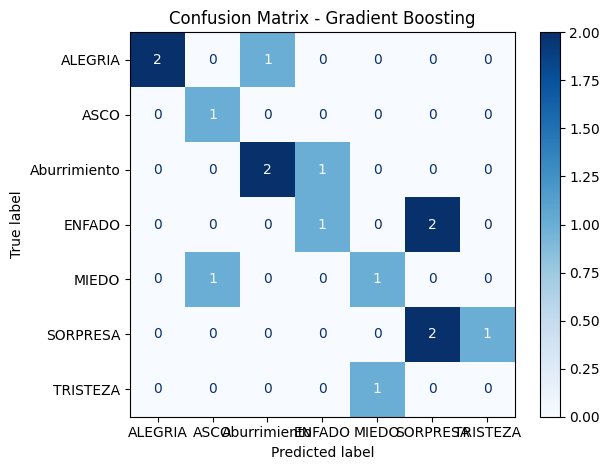

In [69]:
# Importar herramientas para dibujar gráficos y crear la matriz de confusión
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Obtener el nombre del modelo con mejor F1 macro
best_name = results_df.iloc[0]['modelo']

# Recuperar el pipeline correspondiente a ese mejor modelo
best_pipe = trained_models[best_name]

# Hacer predicciones con el mejor modelo sobre el conjunto de prueba
y_pred_best = best_pipe.predict(X_test)

# Obtener la lista de clases presentes en el conjunto de prueba
classes = sorted(y_test.unique())

# Calcular la matriz de confusión comparando valores reales y predichos
cm = confusion_matrix(y_test, y_pred_best, labels=classes)

# Dibujar la matriz de confusión
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.show()

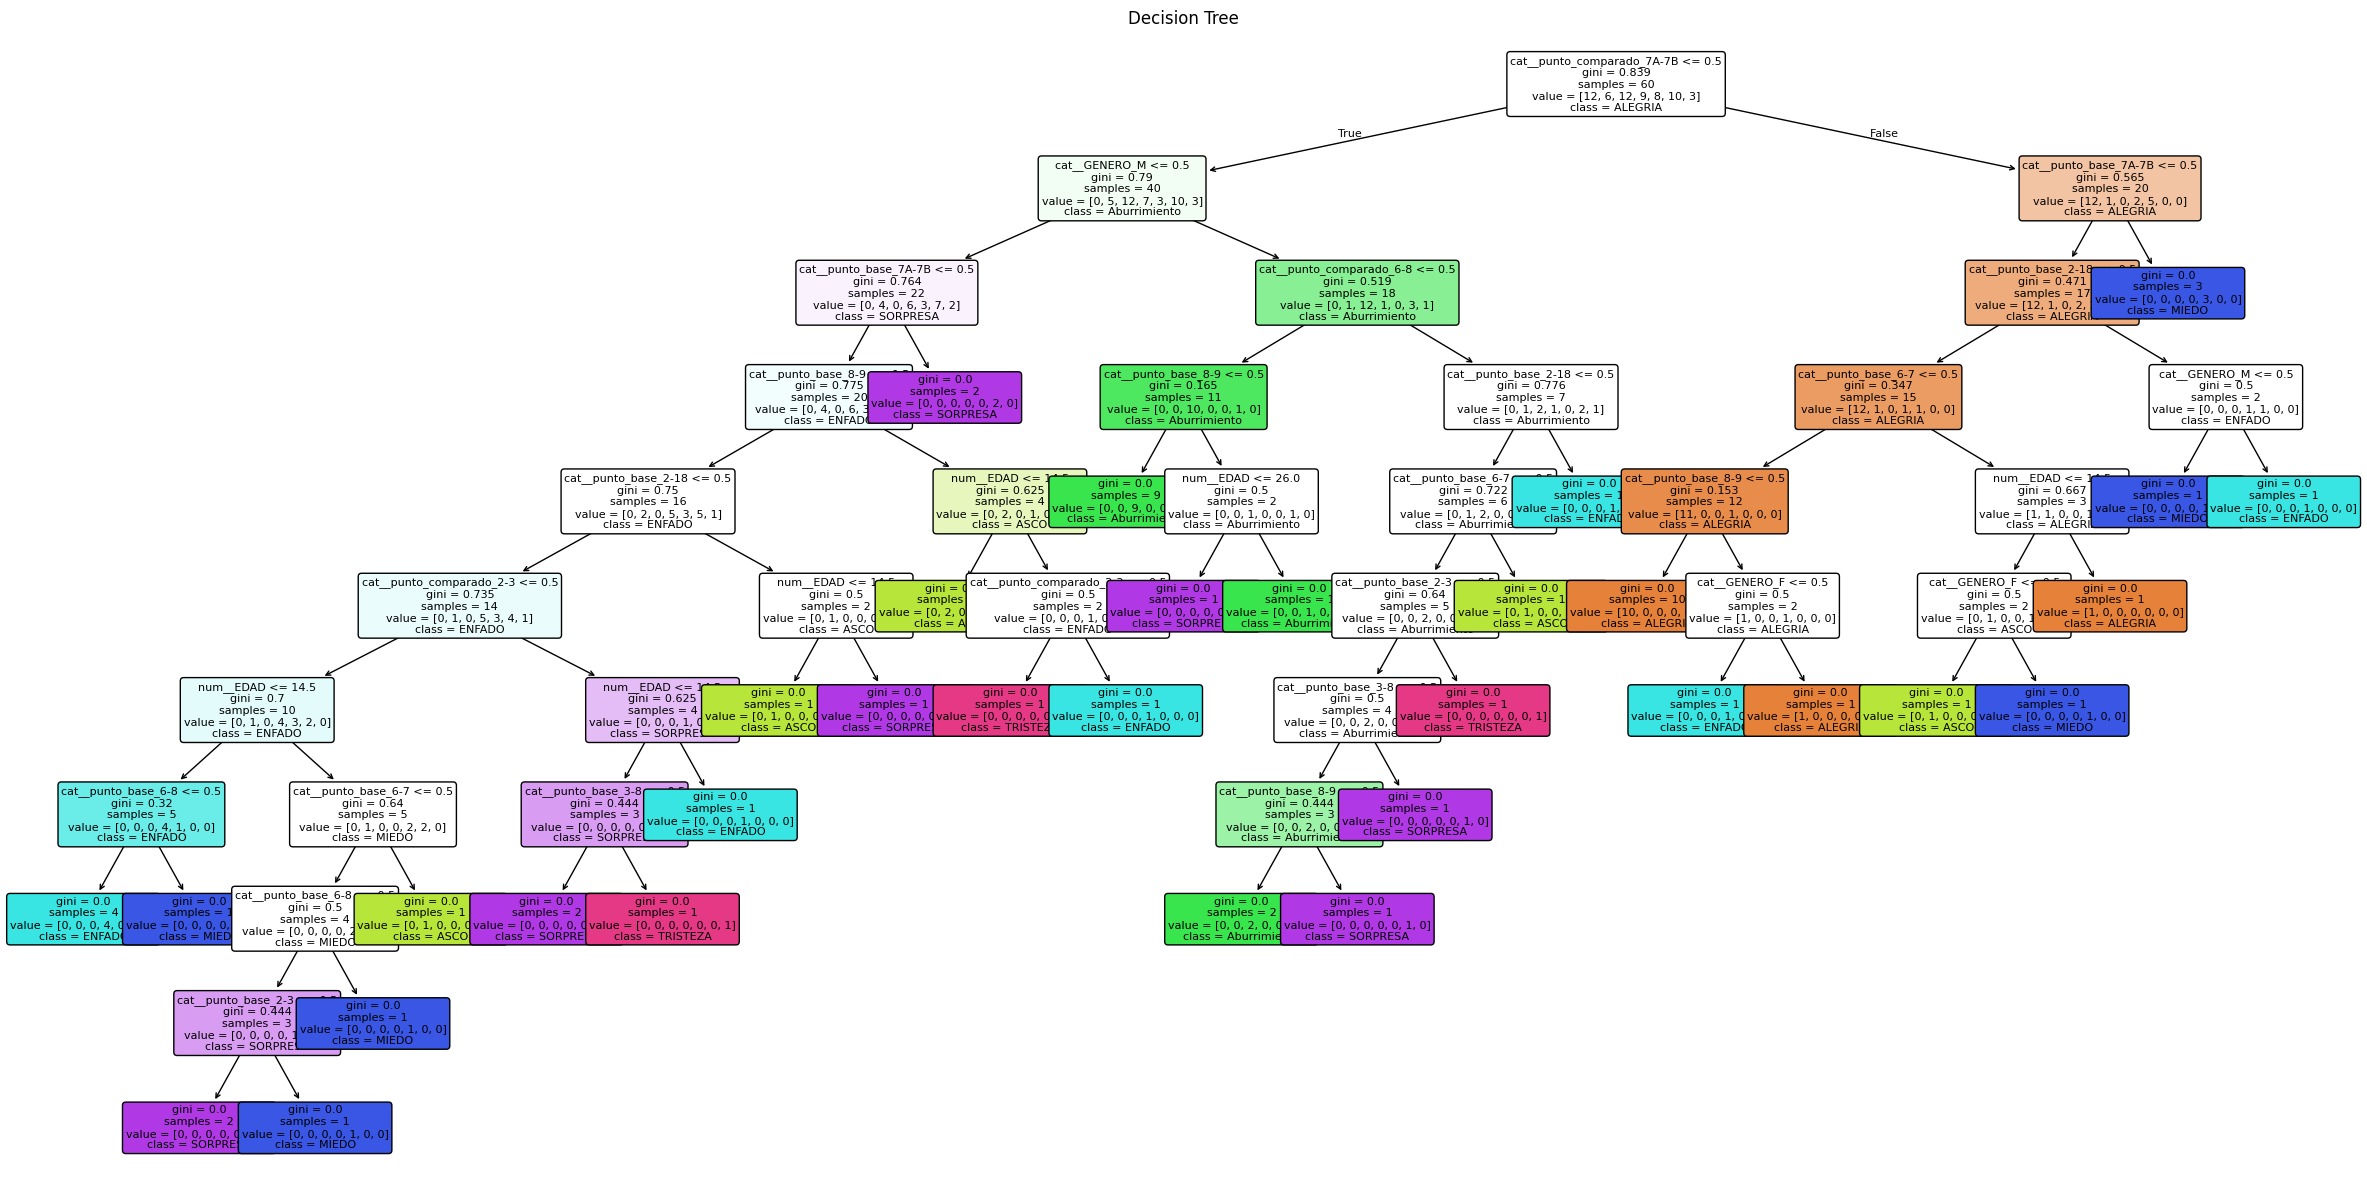

In [70]:
# Importar la función para visualizar árboles de decisión
from sklearn.tree import plot_tree

# Recuperar el pipeline del árbol de decisión ya entrenado
dt_pipe = trained_models['Decision Tree']

# Extraer el modelo entrenado del pipeline
dt_model = dt_pipe.named_steps['model']

# Obtener los nombres de las variables después de aplicar el preprocesamiento
feature_names = dt_pipe.named_steps['preprocess'].get_feature_names_out()

# Crear la figura donde se dibuja el árbol
plt.figure(figsize=(24, 12))

# Dibujar el árbol de decisión con sus características y clases
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=dt_model.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)

# Añadir título y mostrar el gráfico
plt.title('Decision Tree')
plt.tight_layout()
plt.show()

En el árbol de decisión, cada nodo muestra varios valores que ayudan a entender cómo se va tomando la decisión.
Gini indica cuánta mezcla de clases hay en ese nodo: cuanto más bajo es, más “puro” está el grupo, es decir, más ejemplos pertenecen a una sola clase.
Samples muestra cuántos casos hay en ese nodo.
Value indica cuántos ejemplos de cada clase hay dentro del nodo.
Class es la clase que el modelo considera más probable en ese nodo, normalmente la que aparece con más casos.

El árbol funciona haciendo preguntas sucesivas sobre las variables de entrada. En cada división, intenta separar los datos de forma que los grupos resultantes sean lo más homogéneos posible. Así, el árbol va avanzando nodo a nodo hasta llegar a una decisión final, que en este caso será una emoción concreta.

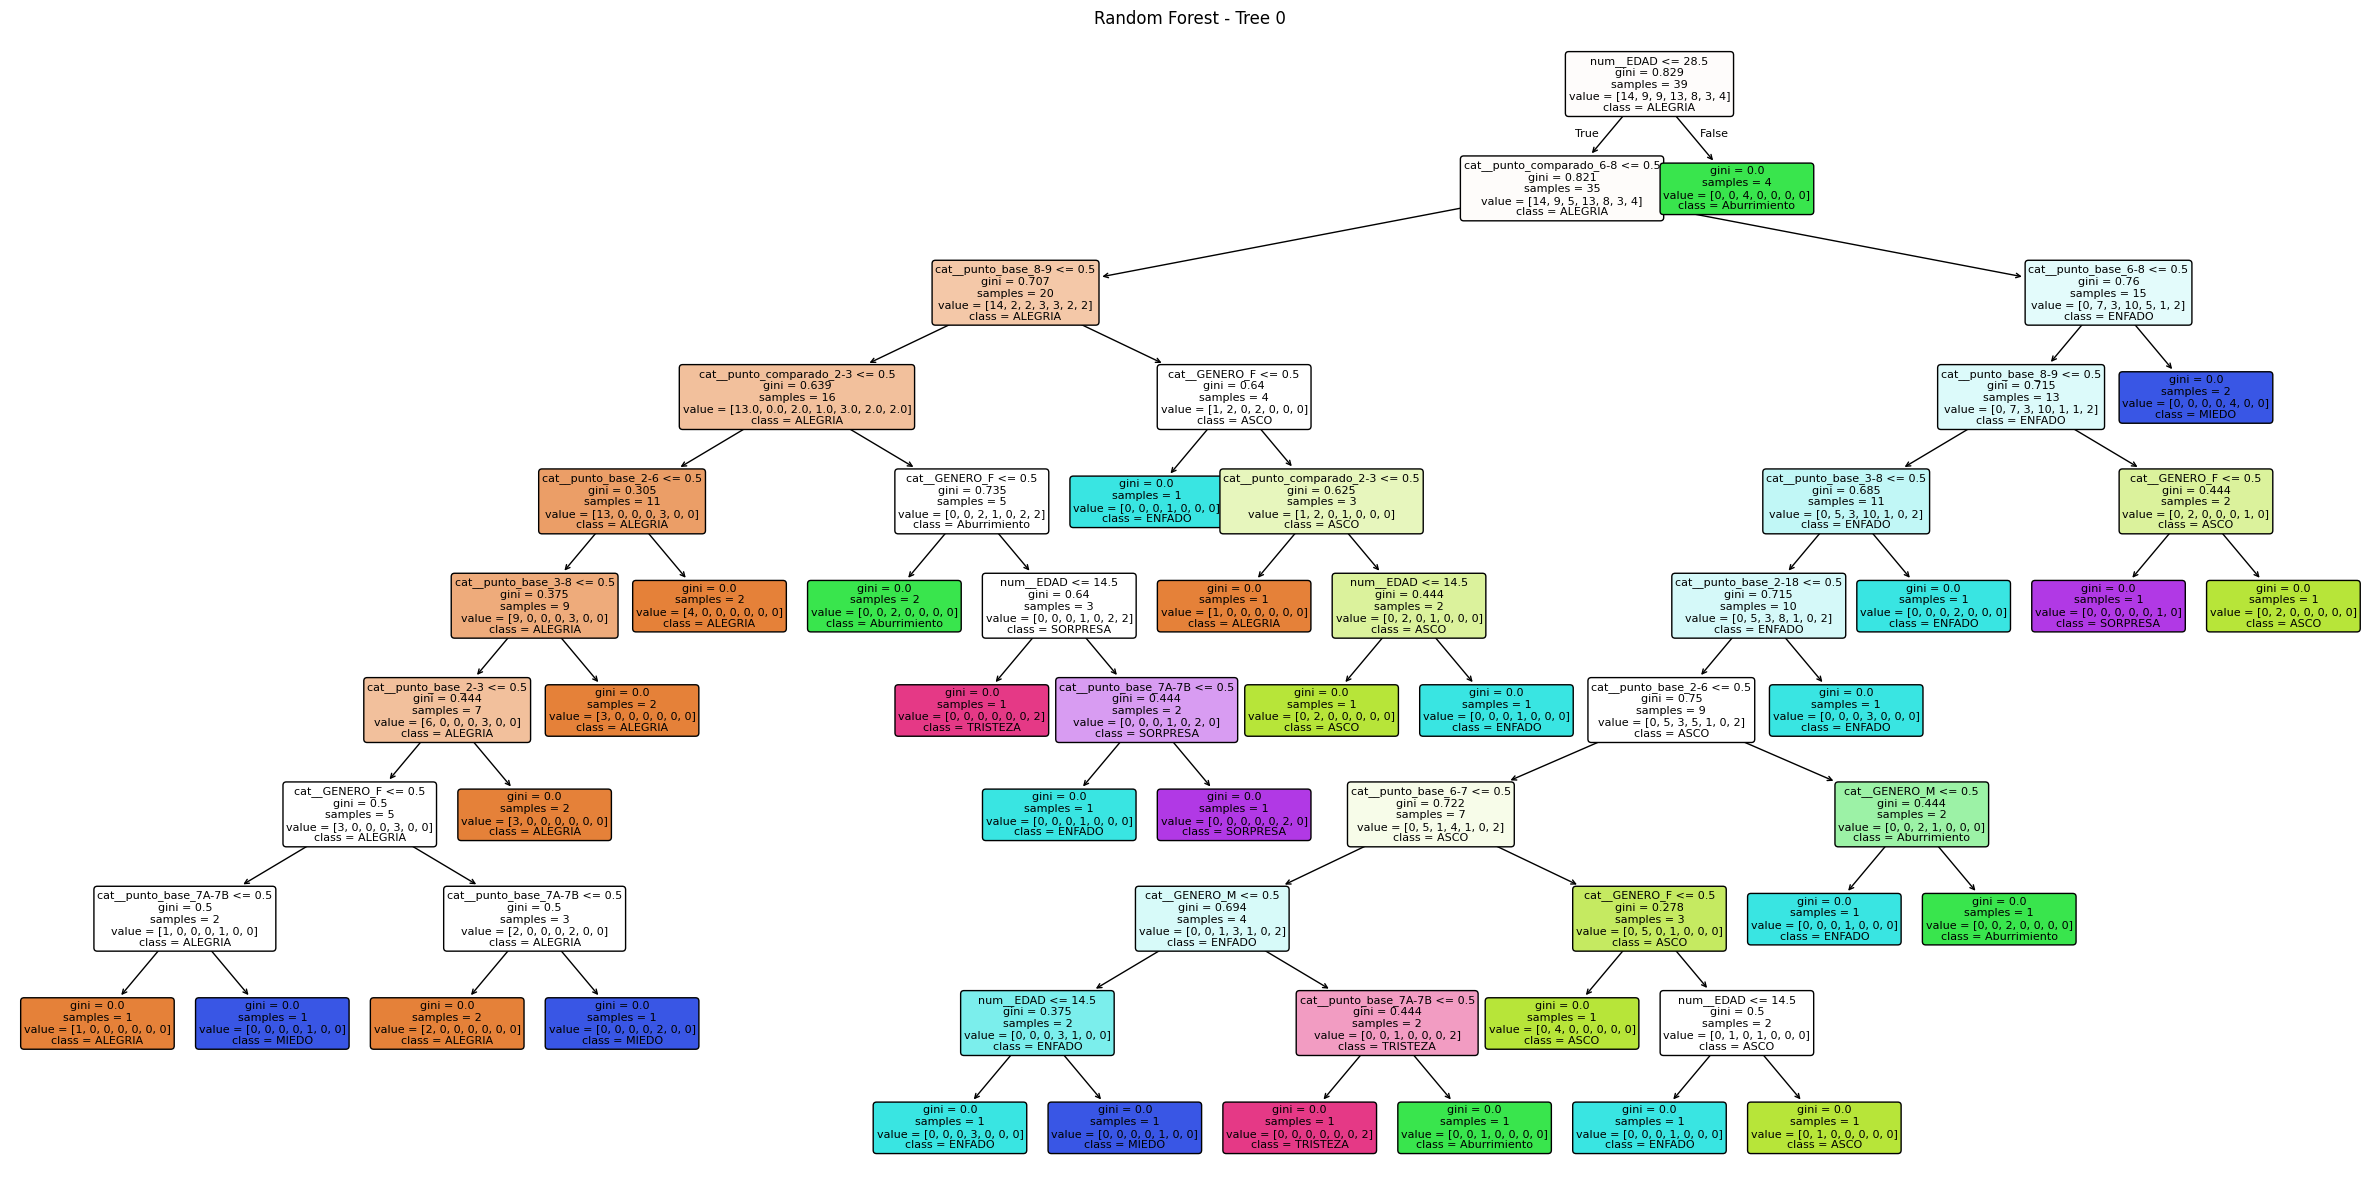

In [71]:
# un árbol del random forest

rf_pipe = trained_models['Random Forest']
rf_model = rf_pipe.named_steps['model']
feature_names = rf_pipe.named_steps['preprocess'].get_feature_names_out()

plt.figure(figsize=(24, 12))
plot_tree(
    rf_model.estimators_[0],
    feature_names=feature_names,
    class_names=rf_model.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Random Forest - Tree 0')
plt.tight_layout()
plt.show()

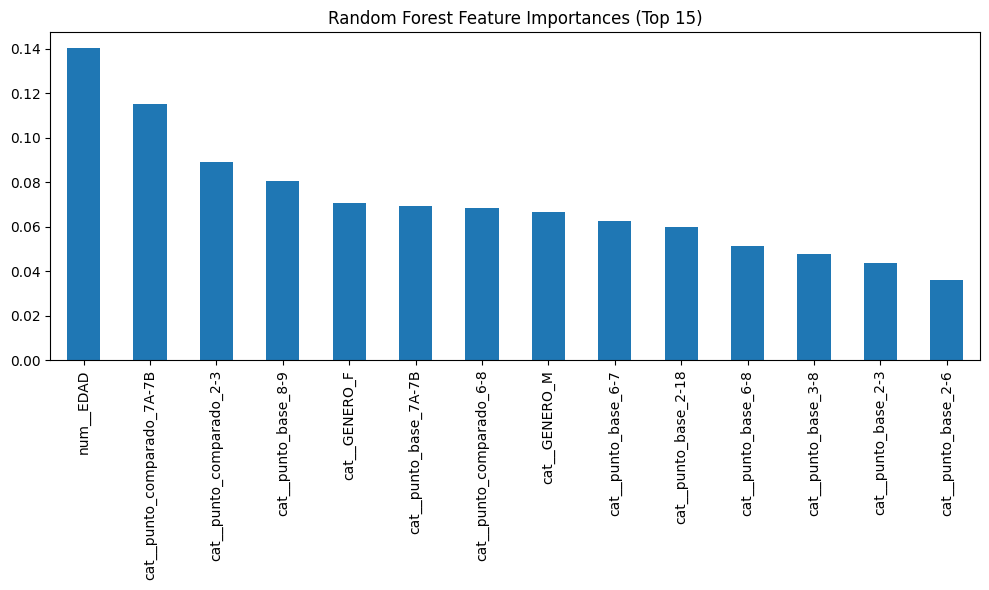

In [72]:
# Importar pandas para trabajar con la serie de importancias
import pandas as pd

# Obtener la importancia de cada variable calculada por el random forest
# y asociarla con el nombre de la característica correspondiente
importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Crear la figura donde se mostrará la gráfica
plt.figure(figsize=(10, 6))

# Dibujar las 15 variables más importantes en forma de barras
importances.head(15).plot(kind='bar')

# Añadir título al gráfico
plt.title('Random Forest Feature Importances (Top 15)')

# Ajustar el diseño para que se vea bien
plt.tight_layout()

# Mostrar la gráfica
plt.show()

La gráfica muestra la importancia de las variables en el modelo Random Forest, es decir, cuánto ha contribuido cada una de ellas a la hora de hacer predicciones correctas. Cuanto más alta es la barra, más peso tiene esa variable en las decisiones del modelo.

En este caso, la variable con mayor importancia es EDAD, lo que indica que es la característica que más influye en la predicción de la emoción dominante. Después aparecen variables como punto_comparado_7A-7B, punto_comparado_2-3 y punto_base_8-9, que también aportan información relevante al modelo. Esto significa que ciertas combinaciones de puntos faciales tienen más capacidad para ayudar a distinguir entre emociones que otras.

También se observa que las variables categóricas derivadas de los puntos faciales aparecen con bastante relevancia, lo que confirma que la relación entre los puntos del rostro y la emoción dominante sí aporta información útil para la clasificación. En cambio, las variables con menor importancia, aunque siguen participando en el modelo, influyen menos en la decisión final.

Esta gráfica no indica causalidad, sino contribución relativa dentro del modelo. Por tanto, sirve para interpretar qué variables han sido más útiles para que el Random Forest aprenda a diferenciar entre emociones como miedo, sorpresa, asco, enfado, tristeza, aburrimiento y alegría.

Comparativa de modelos:
                modelo  accuracy  f1_macro
3    Gradient Boosting    0.5625  0.514966
1        Decision Tree    0.5000  0.353741
2        Random Forest    0.5000  0.339002
0  Logistic Regression    0.4375  0.275510


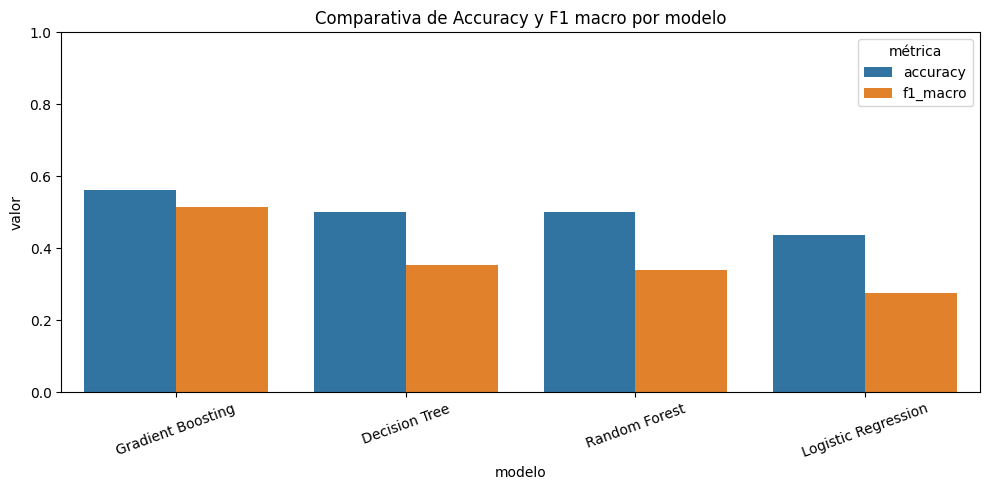

In [73]:
# Importar pandas para manejar la tabla de resultados
import pandas as pd

# Importar matplotlib para crear la figura
import matplotlib.pyplot as plt

# Importar seaborn para dibujar la gráfica de barras de forma más clara
import seaborn as sns

# Hacer una copia de la tabla de resultados para no modificar el original
comparativa = results_df.copy()

# Mostrar por consola la tabla comparativa de los modelos
print("Comparativa de modelos:")
print(comparativa)

# Crear una figura con un tamaño adecuado para visualizar bien los datos
plt.figure(figsize=(10, 5))

# Convertir la tabla a formato largo para poder graficar accuracy y f1_macro en la misma gráfica
comparativa_melt = comparativa.melt(
    id_vars='modelo',
    value_vars=['accuracy', 'f1_macro'],
    var_name='métrica',
    value_name='valor'
)

# Dibujar una gráfica de barras comparando los modelos en ambas métricas
sns.barplot(data=comparativa_melt, x='modelo', y='valor', hue='métrica')

# Limitar el eje Y entre 0 y 1 porque las métricas son proporciones
plt.ylim(0, 1)

# Añadir título a la gráfica
plt.title('Comparativa de Accuracy y F1 macro por modelo')

# Rotar las etiquetas del eje X para que se lean mejor
plt.xticks(rotation=20)

# Ajustar el diseño para evitar solapamientos
plt.tight_layout()

# Mostrar la gráfica
plt.show()

### Explicación de las métricas

- **Accuracy**: indica cuántas veces acierta el modelo en total.  
  Por ejemplo, si el accuracy es 0.56, significa que el modelo acierta en un 56% de los casos.

- **Precision**: indica cuántas veces el modelo acierta cuando predice una emoción concreta.  
  Por ejemplo, si el modelo dice que una imagen es *miedo*, la precision mide cuántas de esas veces realmente era *miedo*.

- **Recall**: indica cuántos casos reales de una emoción consigue detectar el modelo.  
  Por ejemplo, si en realidad había varios casos de *miedo*, el recall mide cuántos de ellos ha sido capaz de encontrar.

- **F1 macro**: combina la precision y el recall de cada emoción y luego hace una media entre todas las clases.  
  Es una métrica muy útil cuando hay varias emociones, porque permite comprobar si el modelo funciona bien de forma equilibrada en todas ellas y no solo en las más frecuentes.

## Conclusión

En este proyecto se ha trabajado con características faciales con el objetivo de predecir la emoción dominante de cada observación. En una primera fase, se intentó abordar el problema utilizando un dataset basado en la diferencia en centímetros entre distintos puntos faciales para cada emoción. Ese planteamiento permitió estructurar el problema de forma inicial, pero no ofreció una representación suficientemente clara de la emoción dominante en cada caso.

Por ello, en una segunda fase se optó por trabajar con un nuevo dataset basado en proporciones entre puntos faciales, que ofrecía una representación más consistente de la información emocional. A partir de este nuevo conjunto de datos, se realizó la limpieza de variables, la conversión de columnas numéricas, la imputación de valores nulos y la creación de una nueva variable objetivo llamada emocion_dominante, definida como la emoción con mayor proporción en cada fila.

Después se compararon cuatro modelos de clasificación multiclase: Regresión Logística, Árbol de Decisión, Random Forest y Gradient Boosting. La evaluación se llevó a cabo mediante las métricas Accuracy y F1 macro, lo que permitió comparar tanto el porcentaje global de aciertos como el equilibrio del rendimiento entre todas las emociones.

Los resultados mostraron que el modelo con mejor comportamiento fue Gradient Boosting, con un accuracy de 0.5625 y un F1 macro de 0.514966. Además, se utilizaron herramientas visuales como la matriz de confusión, la representación del árbol de decisión y la gráfica de importancias de variables del Random Forest para interpretar mejor el comportamiento de los modelos.

En conjunto, el proyecto demuestra que las proporciones entre puntos faciales contienen información útil para la clasificación emocional. Aunque los resultados aún pueden mejorarse, el trabajo realizado permite establecer una base sólida para seguir avanzando. Como líneas futuras, sería recomendable ampliar el tamaño del dataset, ajustar hiperparámetros y aplicar técnicas de validación más robustas para mejorar la capacidad predictiva del modelo.


In [74]:
import pickle

# Guardar el modelo entrenado
with open('modelo_emociones.pkl', 'wb') as f:
    pickle.dump(best_pipe, f)